In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [18]:
df = pd.read_csv(r"travel-insurance.csv")
df.head(20)

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0
5,5,25,Private Sector/Self Employed,No,1150000,4,0,No,No,0
6,6,31,Government Sector,Yes,1300000,4,0,No,No,0
7,7,31,Private Sector/Self Employed,Yes,1350000,3,0,Yes,Yes,1
8,8,28,Private Sector/Self Employed,Yes,1450000,6,1,Yes,Yes,1
9,9,33,Government Sector,Yes,800000,3,0,Yes,No,0


Here follows the list of columns in the dataset:

* Age - Age of the customer
* Employment Type - The sector in which customer is employed
* GraduateOrNot - Whether the customer is college graduate or not
* AnnualIncome - The yearly income of the customer in indian rupees
* FamilyMembers - Number of members in customer's family
* ChronicDisease - Whether the customer suffers from any major disease or conditions like diabetes/high BP or asthama, etc.
* FrequentFlyer - Derived data based on customer's history of booking air tickets on atleast 4 different instances in the last 2 Years (2017-2019).
* EverTravelledAbroad - Has the customer ever travelled to a foreign country.
* TravelInsurance: (label) Did the customer buy travel insurance package during introductory offering held in the year 2019.

In [19]:
df.describe(include="all")

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
count,1987.000000,1987.000000,1987,1987,1.987000e+03,1987.000000,1987.000000,1987,1987,1987.000000
unique,NaN,NaN,2,2,NaN,NaN,NaN,2,2,NaN
top,NaN,NaN,Private Sector/Self Employed,Yes,NaN,NaN,NaN,No,No,NaN
freq,NaN,NaN,1417,1692,NaN,NaN,NaN,1570,1607,NaN
mean,993.000000,29.650226,NaN,NaN,9.327630e+05,4.752894,0.277806,NaN,NaN,0.357323
std,573.741812,2.913308,NaN,NaN,3.768557e+05,1.609650,0.448030,NaN,NaN,0.479332
min,0.000000,25.000000,NaN,NaN,3.000000e+05,2.000000,0.000000,NaN,NaN,0.000000
25%,496.500000,28.000000,NaN,NaN,6.000000e+05,4.000000,0.000000,NaN,NaN,0.000000
50%,993.000000,29.000000,NaN,NaN,9.000000e+05,5.000000,0.000000,NaN,NaN,0.000000
75%,1489.500000,32.000000,NaN,NaN,1.250000e+06,6.000000,1.000000,NaN,NaN,1.000000


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           1987 non-null   int64 
 1   Age                  1987 non-null   int64 
 2   Employment Type      1987 non-null   object
 3   GraduateOrNot        1987 non-null   object
 4   AnnualIncome         1987 non-null   int64 
 5   FamilyMembers        1987 non-null   int64 
 6   ChronicDiseases      1987 non-null   int64 
 7   FrequentFlyer        1987 non-null   object
 8   EverTravelledAbroad  1987 non-null   object
 9   TravelInsurance      1987 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 155.4+ KB


In [21]:
df = df.drop(columns = "Unnamed: 0")
df = df.drop_duplicates()
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


In [22]:
df.isnull().sum()
#there is no missing data in any of the features of this dataset

Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

In [23]:
featureList = df.columns.to_list()

for feature in featureList:
    print(df[f"{feature}"].value_counts())



Age
28    283
34    158
31    148
29    125
33    108
27     91
26     91
25     87
32     67
30     47
35     44
Name: count, dtype: int64
Employment Type
Private Sector/Self Employed    876
Government Sector               373
Name: count, dtype: int64
GraduateOrNot
Yes    1047
No      202
Name: count, dtype: int64
AnnualIncome
500000     90
800000     86
1100000    74
1400000    73
600000     70
1300000    68
1200000    67
550000     58
900000     57
700000     56
1050000    54
750000     48
1250000    47
850000     46
1150000    43
1500000    36
1000000    36
350000     33
400000     31
300000     31
650000     29
1350000    26
1450000    19
950000     19
1700000    15
1750000    15
450000     12
1800000     4
1550000     4
1650000     2
Name: count, dtype: int64
FamilyMembers
4    275
5    243
3    225
6    186
7    140
2     78
8     52
9     50
Name: count, dtype: int64
ChronicDiseases
0    833
1    416
Name: count, dtype: int64
FrequentFlyer
No     954
Yes    295
Name: count, dt

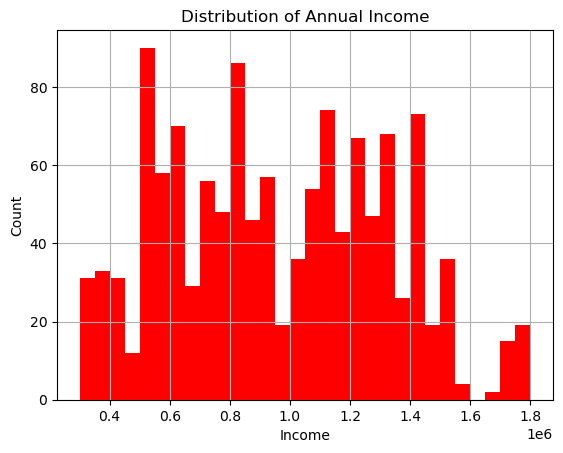

In [24]:
df["AnnualIncome"].hist(bins = 30, color = "red")
plt.title("Distribution of Annual Income")
plt.ylabel("Count")
plt.xlabel("Income")
plt.show()

#exploring numerical feature 1: income
#data is roughly uniform to slightly skewing right. It is also jagged, with some values having significantly
#higher counts than the rest. 

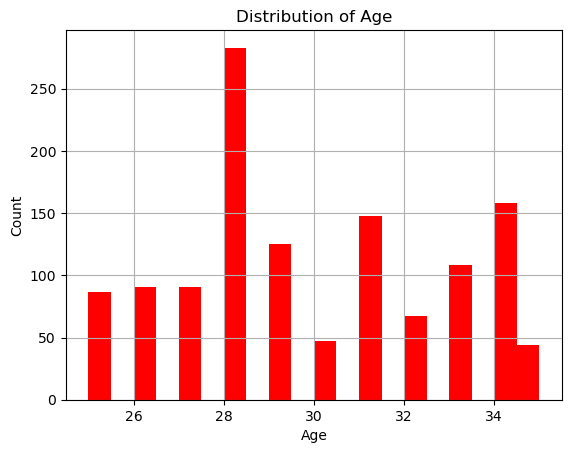

In [25]:
df["Age"].hist(bins = 20, color = "red")
plt.title("Distribution of Age")
plt.ylabel("Count")
plt.xlabel("Age")
plt.show()

#numerical feature 2: age
#age ranges from 25 to 35, 28 has highest count

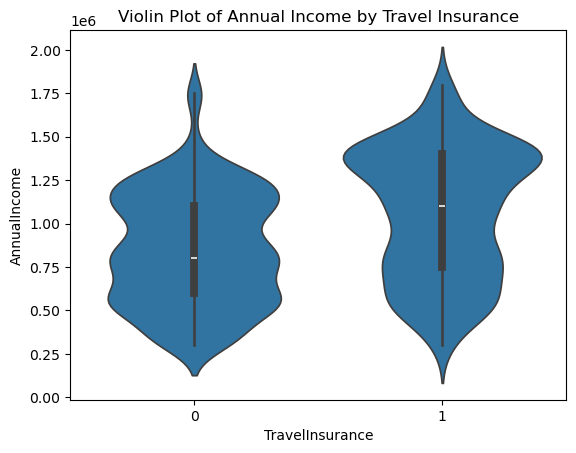

In [26]:
#salary distribution of people who buy insurance vs people who dont
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
sns.violinplot(x="TravelInsurance", y="AnnualIncome", data=df)
plt.title("Violin Plot of Annual Income by Travel Insurance")
plt.show()

#Both distribution have similar range. But, people who buy travel insurance tend to have higher income, the
#insured group's distribution also has higher density at higher values. This suggest people with higher income
#tend to buy travel insurance

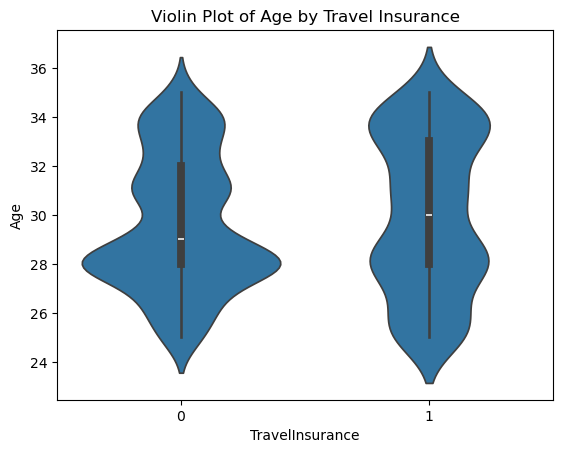

In [27]:
sns.violinplot(x="TravelInsurance", y="Age", data=df)
plt.title("Violin Plot of Age by Travel Insurance")
plt.show()

#Similar range and mean between both groups, but the insured group has higher IQR.  


In [ ]:
catfeatureList = df.select_dtypes(["bool", "object", "category"]).columns.tolist()
for feature in catfeatureList:
    crosstab = pd.crosstab(df[f"{feature}"], df["TravelInsurance"])
    print(crosstab)

#purpose: to see correlation between categorical variables and insurance purchase. It seems a higher proportion of
#people who fly frequently or have travelled abroad have insurance compared to people who dont.

TravelInsurance                 0    1
Employment Type                       
Government Sector             250  123
Private Sector/Self Employed  516  360
TravelInsurance    0    1
GraduateOrNot            
No               131   71
Yes              635  412
TravelInsurance    0    1
FrequentFlyer            
No               618  336
Yes              148  147
TravelInsurance        0    1
EverTravelledAbroad          
No                   689  316
Yes                   77  167


In [ ]:
from sklearn.model_selection import train_test_split
#preprocess data
df_copy = df.copy()
data = pd.get_dummies(data = df_copy, columns = ["Employment Type", "GraduateOrNot", "EverTravelledAbroad", "FrequentFlyer"], dtype = int)

data

,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance,Employment Type_Government Sector,Employment Type_Private Sector/Self Employed,GraduateOrNot_No,GraduateOrNot_Yes,EverTravelledAbroad_No,EverTravelledAbroad_Yes,FrequentFlyer_No,FrequentFlyer_Yes
0,31,400000,6,1,0,1,0,0,1,1,0,1,0
1,31,1250000,7,0,0,0,1,0,1,1,0,1,0
2,34,500000,4,1,1,0,1,0,1,1,0,1,0
3,28,700000,3,1,0,0,1,0,1,1,0,1,0
4,28,700000,8,1,0,0,1,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1976,32,900000,6,0,0,1,0,0,1,1,0,1,0
1981,27,850000,3,0,1,1,0,0,1,1,0,1,0
1982,33,1500000,4,0,1,0,1,0,1,0,1,0,1
1983,28,1750000,5,1,0,0,1,0,1,0,1,1,0


In [ ]:
''' 
The independence assumption mostly holds for this dataset, since correlation coefficients between variables
mostly fall around near-0 to around plus/minus 0.2 (which is weak). The only noticeable correlation coefficients 
are those between EverTravelledAbroad, FrequentFlyer, and EmploymentType with AnnualIncome (around plus/minus 0.3
to plus/minus 0.4, which is moderate).
'''
data.corr()

In [30]:
feature_names = data.columns.tolist()
feature_names.remove("TravelInsurance")
X = data[feature_names]
y = data["TravelInsurance"]


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print(type(X))
X_train_val, X_val, y_train_val, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state=1) 
#the second split is for mixednb, because the mixednb from the mixed_naive_bayes library does not support
#GridSearchCV() I will use manual validation for it.

<class 'pandas.core.frame.DataFrame'>


In [32]:

#Normalizing numeric data
from sklearn.preprocessing import StandardScaler
num_cols = ["Age", "AnnualIncome", "FamilyMembers"]
#normalize only numerics

normalizer = StandardScaler()

X_train[num_cols] = normalizer.fit_transform(X_train[num_cols])
X_test[num_cols] = normalizer.transform(X_test[num_cols])
X_train_val[num_cols] = normalizer.transform(X_train_val[num_cols])


In [33]:
# Your code goes here
# 1.3
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

gridsearch = {
    "var_smoothing": [0, 1e-09, 1e-08, 1e-07, 1e-06],
    "priors": [None, [0.1, 0.9], [0.2, 0.8], [0.3, 0.7], [0.4, 0.6], [0.5, 0.5], [0.9, 0.1], [0.8, 0.2], [0.7, 0.3], [0.6, 0.4]]
}
gaussiannb = GaussianNB()
gaussiannbCV = GridSearchCV(gaussiannb, gridsearch, cv=10)

gaussiannbCV.fit(X_train, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'priors': [None, [0.1, 0.9], ...], 'var_smoothing': [0, 1e-09, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [34]:
print(gaussiannbCV.best_params_)
print(gaussiannbCV.best_score_)

{'priors': [0.9, 0.1], 'var_smoothing': 0}
0.6926969696969697


In [35]:
gaussiannb = GaussianNB(priors=[0.9, 0.1], var_smoothing=0)
gaussiannb.fit(X_train, y_train)
gaussiannb.score(X_test, y_test)

0.704

In [ ]:
# Your code goes here
# 1.4

from mixed_naive_bayes import MixedNB
mixednb = MixedNB(categorical_features=[3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

hyperparameters = {
    "var_smoothing": [0, 1e-09, 1e-08, 1e-07, 1e-06],
    "priors": [None, [0.1, 0.9], [0.2, 0.8], [0.3, 0.7], [0.4, 0.6], [0.5, 0.5], [0.9, 0.1], [0.8, 0.2], [0.7, 0.3], [0.6, 0.4]],        
    "alpha": [0.0, 1e-3, 1e-2, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

results = []

for vm in hyperparameters["var_smoothing"]:
    for prior in hyperparameters["priors"]:
        for alphavalue in hyperparameters["alpha"]:
            # Initialize model
            mixednbCV = MixedNB(alpha=alphavalue, var_smoothing=vm, priors=prior)

            # Train and get score
            mixednbCV.fit(X_train_val, y_train_val)
            score = float(mixednbCV.score(X_val, y_val))

            

            # Save result
            results.append({
                "alpha": alphavalue,
                "var_smoothing": vm,
                "priors": prior,
                "accuracy": score
            })

print(results)

sorted_results = sorted(results, key=lambda x: x["accuracy"], reverse = True)
best = sorted_results[0]
print(best)






[{'alpha': 0.0, 'var_smoothing': 0, 'priors': None, 'accuracy': 0.56}, {'alpha': 0.001, 'var_smoothing': 0, 'priors': None, 'accuracy': 0.56}, {'alpha': 0.01, 'var_smoothing': 0, 'priors': None, 'accuracy': 0.56}, {'alpha': 0.1, 'var_smoothing': 0, 'priors': None, 'accuracy': 0.56}, {'alpha': 0.5, 'var_smoothing': 0, 'priors': None, 'accuracy': 0.56}, {'alpha': 1.0, 'var_smoothing': 0, 'priors': None, 'accuracy': 0.56}, {'alpha': 2.0, 'var_smoothing': 0, 'priors': None, 'accuracy': 0.56}, {'alpha': 5.0, 'var_smoothing': 0, 'priors': None, 'accuracy': 0.56}, {'alpha': 10.0, 'var_smoothing': 0, 'priors': None, 'accuracy': 0.56}, {'alpha': 0.0, 'var_smoothing': 0, 'priors': [0.1, 0.9], 'accuracy': 0.56}, {'alpha': 0.001, 'var_smoothing': 0, 'priors': [0.1, 0.9], 'accuracy': 0.56}, {'alpha': 0.01, 'var_smoothing': 0, 'priors': [0.1, 0.9], 'accuracy': 0.56}, {'alpha': 0.1, 'var_smoothing': 0, 'priors': [0.1, 0.9], 'accuracy': 0.56}, {'alpha': 0.5, 'var_smoothing': 0, 'priors': [0.1, 0.9], '

/home/hoangpham219/miniconda3/envs/ml_ai_fuv/lib/python3.12/site-packages/mixed_naive_bayes/mixed_naive_bayes.py:367: UserWarning: alpha too small will result in numeric errors, setting alpha = 1e-10
  warnings.warn('alpha too small will result in numeric errors, '
/home/hoangpham219/miniconda3/envs/ml_ai_fuv/lib/python3.12/site-packages/mixed_naive_bayes/mixed_naive_bayes.py:275: RuntimeWarning: invalid value encountered in divide
  normalised = finals/finals.sum(axis=1, keepdims=True)


In [37]:
#best hyperparameters for mixedNB is 'alpha': 0.0, 'var_smoothing': 0, 'priors': None

mixednb = MixedNB(categorical_features=[3, 4, 5, 6, 7, 8, 9, 10, 11], alpha = 0.0, var_smoothing=0, priors=None)

mixednb.fit(X_train, y_train)
mixednb.score(X_test, y_test)

np.float64(0.652)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

predicted_label_GaussianNB = gaussiannb.predict(X_test)

print(precision_score(y_test, predicted_label_GaussianNB))
print(recall_score(y_test, predicted_label_GaussianNB))
print(f1_score(y_test, predicted_label_GaussianNB))
print(classification_report(y_test, predicted_label_GaussianNB))


0.7166666666666667
0.43
0.5375
              precision    recall  f1-score   support

           0       0.70      0.89      0.78       150
           1       0.72      0.43      0.54       100

    accuracy                           0.70       250
   macro avg       0.71      0.66      0.66       250
weighted avg       0.71      0.70      0.68       250



In [39]:
predicted_label_MixedNB = mixednb.predict(X_test)

print(precision_score(y_test, predicted_label_MixedNB))
print(recall_score(y_test, predicted_label_MixedNB))
print(f1_score(y_test, predicted_label_MixedNB))
print(classification_report(y_test, predicted_label_MixedNB))

0.5822784810126582
0.46
0.5139664804469274
              precision    recall  f1-score   support

           0       0.68      0.78      0.73       150
           1       0.58      0.46      0.51       100

    accuracy                           0.65       250
   macro avg       0.63      0.62      0.62       250
weighted avg       0.64      0.65      0.64       250



In [40]:
''' 
Unexpectedly, the gaussian nb model performed equal or better than mixed nb, except for recall score for class 1 where
mixed nb edged out by 0.3. Overall, both models performed very well for class 0, but struggled way more with class 0
'''

' \nUnexpectedly, the gaussian nb model performed equal or better than mixed nb, except for recall score for class 1 where\nmixed nb edged out by 0.3. Overall, both models performed very well for class 0, but struggled way more with class 0\n'

In [ ]:
''' 
Some observations:
- According to my EDA (see contingency tables and violin plot above) and the correlation table
below, FrequentFlyer, EverTravelledAbroad, and Income, in my opinion, has the most impact on whether
someone buys insurance. According to the contingency tables, ratios of people who who are frequent fliers
and have travelled abroad are significantly higher than those who answered otherwise. Furthermore, the income
of those with travel insurance is also significantly higher. This is common sense, as people with more money 
would be able to better afford insurance and those who travel frequently would want a safety net if something
bad happens.

- What I found interesting in this dataset is the fact that the age range is fairly small (25 to 35) 
(see bar chart in part 1) and the fact that whether a person has chronic disease has little correlation with
whether they buy travel insurance, since having chronic diseases mean that there are more risks involve when
one does travel. For the first point, it could have been that the samplers were unable to record data from older 
demographics. For example, the sampling might have taken place through an online form and older people are less
likely to be willing to fill in those forms, or they may have less time than younger people due to familial and
work duties, or it could be that the scope of this dataset is only people from 25 to 35 years of age. For the 
second observation, I initially thought that people with chronic diseases are less likely to travel. However, 
upon looking at the correlation table, I do not see such a correlation. An explanation I have is that insurance 
companies exclude certain pre-existing conditions in their policies, and there would be no reason for people 
with those conditions to buy insurance if they dont cover what they actually need. 
'''